# Ironhack Payments Analysis
Project by Tony Vargas & Alba Sentis

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from ydata_profiling import ProfileReport
import warnings

In [3]:
df_cash = pd.read_csv("./project_dataset/extract - cash request - data analyst.csv")
df_fees = pd.read_csv("./project_dataset/extract - fees - data analyst - .csv")

In [4]:
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

## Project Definition
In this project, we'll conduct a comprehensive cohort analysis based on data provided by IronHack Payments. The primary goal is to analyze cohorts of users defined by the month they first requested a cash advance. We'll track the monthly evolution of key metrics for these cohorts, enabling IronHack Payments to gain valuable insights into user behavior and the performance of their financial services.

## Exploratory Data Analysis (EDA)

In [7]:
df_cash.head(5)

,id,amount,status,created_at,updated_at,user_id,moderated_at,deleted_account_id,reimbursement_date,cash_request_received_date,money_back_date,transfer_type,send_at,recovery_status,reco_creation,reco_last_update
0,5,100.0,rejected,2019-12-10 19:05:21.596873+00,2019-12-11 16:47:42.40783+00,804.0,2019-12-11 16:47:42.405646+00,NaN,2020-01-09 19:05:21.596363+00,NaN,NaN,regular,NaN,NaN,NaN,NaN
1,70,100.0,rejected,2019-12-10 19:50:12.34778+00,2019-12-11 14:24:22.900054+00,231.0,2019-12-11 14:24:22.897988+00,NaN,2020-01-09 19:50:12.34778+00,NaN,NaN,regular,NaN,NaN,NaN,NaN
2,7,100.0,rejected,2019-12-10 19:13:35.82546+00,2019-12-11 09:46:59.779773+00,191.0,2019-12-11 09:46:59.777728+00,NaN,2020-01-09 19:13:35.825041+00,NaN,NaN,regular,NaN,NaN,NaN,NaN
3,10,99.0,rejected,2019-12-10 19:16:10.880172+00,2019-12-18 14:26:18.136163+00,761.0,2019-12-18 14:26:18.128407+00,NaN,2020-01-09 19:16:10.879606+00,NaN,NaN,regular,NaN,NaN,NaN,NaN
4,1594,100.0,rejected,2020-05-06 09:59:38.877376+00,2020-05-07 09:21:55.34008+00,7686.0,2020-05-07 09:21:55.320193+00,NaN,2020-06-05 22:00:00+00,NaN,NaN,regular,NaN,NaN,NaN,NaN


In [8]:
df_cash.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23970 entries, 0 to 23969
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          23970 non-null  int64  
 1   amount                      23970 non-null  float64
 2   status                      23970 non-null  object 
 3   created_at                  23970 non-null  object 
 4   updated_at                  23970 non-null  object 
 5   user_id                     21867 non-null  float64
 6   moderated_at                16035 non-null  object 
 7   deleted_account_id          2104 non-null   float64
 8   reimbursement_date          23970 non-null  object 
 9   cash_request_received_date  16289 non-null  object 
 10  money_back_date             16543 non-null  object 
 11  transfer_type               23970 non-null  object 
 12  send_at                     16641 non-null  object 
 13  recovery_status             333

In [9]:
df_cash.describe()

,id,amount,user_id,deleted_account_id
count,23970.000000,23970.000000,21867.000000,2104.000000
mean,13910.966124,82.720818,32581.250789,9658.755228
std,7788.117214,26.528065,27618.565773,7972.743249
min,3.000000,1.000000,34.000000,91.000000
25%,7427.250000,50.000000,10804.000000,3767.000000
50%,14270.500000,100.000000,23773.000000,6121.500000
75%,20607.750000,100.000000,46965.000000,16345.000000
max,27010.000000,200.000000,103719.000000,30445.000000


In [10]:
df_fees.head(5)

,id,cash_request_id,type,status,category,total_amount,reason,created_at,updated_at,paid_at,from_date,to_date,charge_moment
0,6537,14941.0,instant_payment,rejected,NaN,5.0,Instant Payment Cash Request 14941,2020-09-07 10:47:27.42315+00,2020-10-13 14:25:09.396112+00,2020-12-17 14:50:07.47011+00,NaN,NaN,after
1,6961,11714.0,incident,accepted,rejected_direct_debit,5.0,rejected direct debit,2020-09-09 20:51:17.998653+00,2020-10-13 14:25:15.537063+00,2020-12-08 17:13:10.45908+00,NaN,NaN,after
2,16296,23371.0,instant_payment,accepted,NaN,5.0,Instant Payment Cash Request 23371,2020-10-23 10:10:58.352972+00,2020-10-23 10:10:58.352994+00,2020-11-04 19:34:37.43291+00,NaN,NaN,after
3,20775,26772.0,instant_payment,accepted,NaN,5.0,Instant Payment Cash Request 26772,2020-10-31 15:46:53.643958+00,2020-10-31 15:46:53.643982+00,2020-11-19 05:09:22.500223+00,NaN,NaN,after
4,11242,19350.0,instant_payment,accepted,NaN,5.0,Instant Payment Cash Request 19350,2020-10-06 08:20:17.170432+00,2020-10-13 14:25:03.267983+00,2020-11-02 14:45:20.355598+00,NaN,NaN,after


In [11]:
df_fees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21061 entries, 0 to 21060
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               21061 non-null  int64  
 1   cash_request_id  21057 non-null  float64
 2   type             21061 non-null  object 
 3   status           21061 non-null  object 
 4   category         2196 non-null   object 
 5   total_amount     21061 non-null  float64
 6   reason           21061 non-null  object 
 7   created_at       21061 non-null  object 
 8   updated_at       21061 non-null  object 
 9   paid_at          15531 non-null  object 
 10  from_date        7766 non-null   object 
 11  to_date          7766 non-null   object 
 12  charge_moment    21061 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 2.1+ MB


In [12]:
df_fees.describe()

,id,cash_request_id,total_amount
count,21061.000000,21057.000000,21061.000000
mean,10645.355111,16318.449162,5.000237
std,6099.315256,6656.149949,0.034453
min,1.000000,1456.000000,5.000000
25%,5385.000000,11745.000000,5.000000
50%,10652.000000,17160.000000,5.000000
75%,15925.000000,21796.000000,5.000000
max,21193.000000,27010.000000,10.000000


We observed that the two dataframes share the columns cash_request_id, created_at, and status, so we decided to merge them based on these common fields.

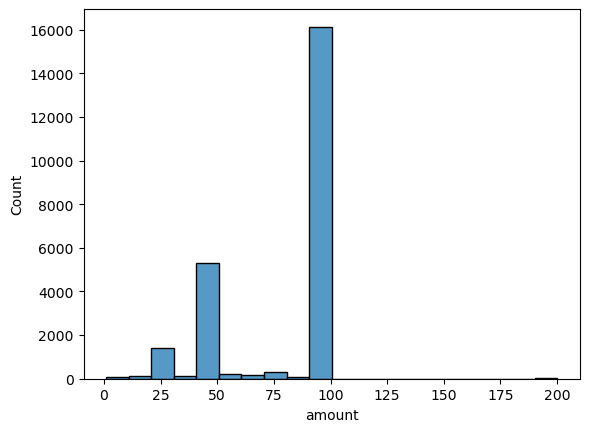

<Axes: ylabel='amount'>

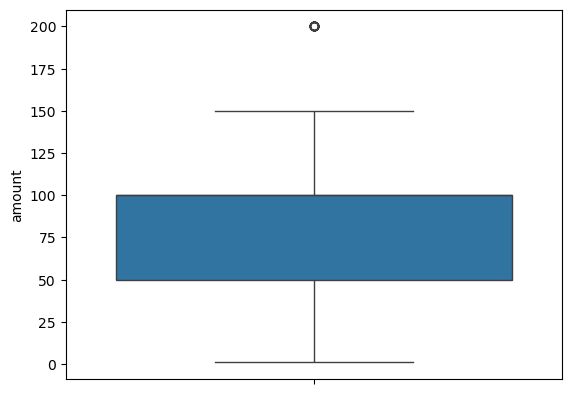

In [14]:
# Visualization of the distribution of the amount column
# Histogram
sns.histplot(df_cash['amount'], bins=20)
plt.show()
# Boxplot
sns.boxplot(df_cash['amount'])

As shown in these charts, the majority of cash request amounts are approximately €100.

In [16]:
# Fill the NaN values in 'user_id' with the values from 'deleted_account_id'
df_cash['user_id'] = df_cash['user_id'].fillna(df_cash['deleted_account_id'])

# Convert the 'created_at' column to datetime
df_cash['created_at'] = pd.to_datetime(df_cash['created_at'])

# Create a new column 'year_month' that extracts the year and month from 'created_at'
df_cash['year_month'] = df_cash['created_at'].dt.to_period('M')

# Group by 'user_id' and find the earliest 'year_month' for each user
first_cash_request_month = df_cash.groupby('user_id')['year_month'].min().reset_index()

# Rename the columns for clarity
first_cash_request_month.columns = ['user_id', 'first_cash_request_month']

# Merge the earliest month back into the original DataFrame
df_cash = df_cash.merge(first_cash_request_month, on='user_id', how='left')

In [17]:
df_cash

,id,amount,status,created_at,updated_at,user_id,moderated_at,deleted_account_id,reimbursement_date,cash_request_received_date,money_back_date,transfer_type,send_at,recovery_status,reco_creation,reco_last_update,year_month,first_cash_request_month
0,5,100.0,rejected,2019-12-10 19:05:21.596873+00:00,2019-12-11 16:47:42.40783+00,804.0,2019-12-11 16:47:42.405646+00,NaN,2020-01-09 19:05:21.596363+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,2019-12,2019-12
1,70,100.0,rejected,2019-12-10 19:50:12.347780+00:00,2019-12-11 14:24:22.900054+00,231.0,2019-12-11 14:24:22.897988+00,NaN,2020-01-09 19:50:12.34778+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,2019-12,2019-12
2,7,100.0,rejected,2019-12-10 19:13:35.825460+00:00,2019-12-11 09:46:59.779773+00,191.0,2019-12-11 09:46:59.777728+00,NaN,2020-01-09 19:13:35.825041+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,2019-12,2019-12
3,10,99.0,rejected,2019-12-10 19:16:10.880172+00:00,2019-12-18 14:26:18.136163+00,761.0,2019-12-18 14:26:18.128407+00,NaN,2020-01-09 19:16:10.879606+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,2019-12,2019-12
4,1594,100.0,rejected,2020-05-06 09:59:38.877376+00:00,2020-05-07 09:21:55.34008+00,7686.0,2020-05-07 09:21:55.320193+00,NaN,2020-06-05 22:00:00+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,2020-05,2020-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23965,20616,100.0,money_back,2020-10-12 13:54:11.686225+00:00,2021-02-06 20:17:49.292493+00,13681.0,NaN,NaN,2021-02-06 11:00:00+00,2020-10-13,2021-02-06 20:17:49.257521+00,instant,2020-10-12 13:54:24.352856+00,NaN,NaN,NaN,2020-10,2020-06
23966,25243,50.0,money_back,2020-10-27 14:41:25.734910+00:00,2020-12-18 13:15:40.843946+00,30367.0,NaN,30367.0,2020-11-03 22:00:00+00,2020-10-28,2020-12-01 13:26:53.787672+00,instant,2020-10-27 14:41:57.901946+00,completed,2020-11-12 23:20:41.928788+00,2020-12-01 13:26:53.815504+00,2020-10,2020-10
23967,22357,100.0,money_back,2020-10-20 07:58:04.006937+00:00,2021-02-05 12:19:30.656816+00,82122.0,NaN,NaN,2021-02-05 11:00:00+00,2020-10-21,2021-02-05 12:19:30.626289+00,instant,2020-10-20 07:58:14.171553+00,NaN,NaN,NaN,2020-10,2020-10
23968,20256,100.0,money_back,2020-10-10 05:40:55.700422+00:00,2021-02-05 13:14:19.707627+00,64517.0,NaN,NaN,2021-02-05 11:00:00+00,2020-10-12,2021-02-05 13:14:19.689906+00,instant,2020-10-10 05:41:23.368363+00,NaN,NaN,NaN,2020-10,2020-10


<Axes: xlabel='year_month'>

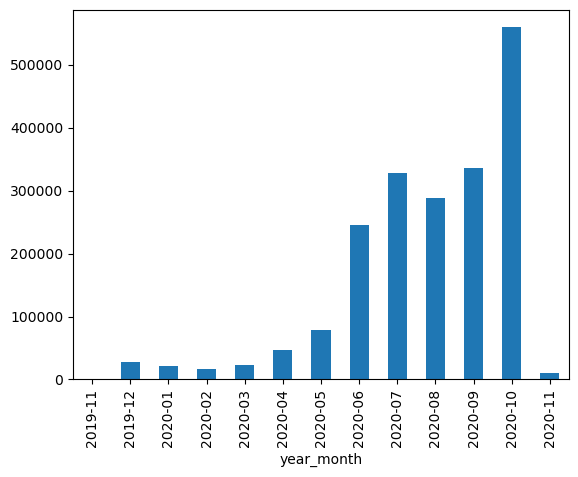

In [18]:
# Group the data by 'year_month', sum the 'amount' for each month, and plot it as a bar chart
df_cash.groupby('year_month')['amount'].sum().plot(kind='bar')

We also observe that October 2020 marked the peak in the number of cash requests. It would be interesting to investigate whether this spike is related to a marketing campaign.

## Data Quality Analysis

In [21]:
df_cash.isnull().sum()

id                                0
amount                            0
status                            0
created_at                        0
updated_at                        0
user_id                           0
moderated_at                   7935
deleted_account_id            21866
reimbursement_date                0
cash_request_received_date     7681
money_back_date                7427
transfer_type                     0
send_at                        7329
recovery_status               20640
reco_creation                 20640
reco_last_update              20640
year_month                        0
first_cash_request_month          0
dtype: int64

We discovered that there are 2.103 null values in the user_id column, which correspond to entries in the deleted_account_id column. Later in the project, we handled these null values by copying the IDs from the deleted_account_id column to the user_id column to manage the missing data.

In [23]:
df_fees.isnull().sum()

id                     0
cash_request_id        4
type                   0
status                 0
category           18865
total_amount           0
reason                 0
created_at             0
updated_at             0
paid_at             5530
from_date          13295
to_date            13295
charge_moment          0
dtype: int64

In [24]:
df_cash.dtypes

id                                          int64
amount                                    float64
status                                     object
created_at                    datetime64[ns, UTC]
updated_at                                 object
user_id                                   float64
moderated_at                               object
deleted_account_id                        float64
reimbursement_date                         object
cash_request_received_date                 object
money_back_date                            object
transfer_type                              object
send_at                                    object
recovery_status                            object
reco_creation                              object
reco_last_update                           object
year_month                              period[M]
first_cash_request_month                period[M]
dtype: object

In [25]:
df_fees.dtypes

id                   int64
cash_request_id    float64
type                object
status              object
category            object
total_amount       float64
reason              object
created_at          object
updated_at          object
paid_at             object
from_date           object
to_date             object
charge_moment       object
dtype: object

In [26]:
df_fees.duplicated().sum()

0

In [27]:
df_cash.duplicated().sum()

0

We can see that the date columns are not in Datetime format, so we will need to convert them. However, there are no duplicates present. Overall, the quality of the dataframes is good.

## Merging the DataFrames

In [30]:
# Rename columns in the two DataFrames for better clarity and consistency
df_cash = (df_cash
           .rename(columns={"id": "cash_request_id", "amount": "cash_amount", "status": "cash_status", "created_at" : "cash_created_at", "updated_at": "cash_updated_at"})
           .drop(columns=["moderated_at", "deleted_account_id"]) 
)

df_fees = (df_fees
           .rename(columns={"id": "fees_id","status": "fees_status", "created_at" : "fees_created_at", "updated_at": "fees_updated_at"})
           .drop(columns=["charge_moment"])
)

# Merge the two DataFrames
df_combined = pd.merge(df_cash, df_fees, on='cash_request_id', how='outer')

In [31]:
# Fill rows in the "type" column with "cash_request" to indicate that these rows come from the cash_df
df_combined["type"] = df_combined["type"].fillna("cash_request")

In [32]:
df_combined.head(5)

,cash_request_id,cash_amount,cash_status,cash_created_at,cash_updated_at,user_id,reimbursement_date,cash_request_received_date,money_back_date,transfer_type,send_at,recovery_status,reco_creation,reco_last_update,year_month,first_cash_request_month,fees_id,type,fees_status,category,total_amount,reason,fees_created_at,fees_updated_at,paid_at,from_date,to_date
0,3.0,1.0,canceled,2019-11-19 13:57:53.511561+00:00,2020-12-14 10:25:57.710844+00,47.0,2019-12-05 23:00:00+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,2019-11,2019-11,NaN,cash_request,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.0,100.0,money_back,2019-12-09 14:47:35.190714+00:00,2020-11-04 12:54:52.120014+00,1309.0,2019-12-16 23:00:00+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,2019-12,2019-12,NaN,cash_request,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5.0,100.0,rejected,2019-12-10 19:05:21.596873+00:00,2019-12-11 16:47:42.40783+00,804.0,2020-01-09 19:05:21.596363+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,2019-12,2019-12,NaN,cash_request,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6.0,100.0,direct_debit_rejected,2019-12-10 19:05:48.921042+00:00,2020-12-18 22:47:47.993817+00,812.0,2020-02-05 23:00:00+00,2019-12-11,NaN,regular,NaN,pending,2020-03-20 14:12:53.208246+00,2020-12-18 22:47:48.00885+00,2019-12,2019-12,NaN,cash_request,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7.0,100.0,rejected,2019-12-10 19:13:35.825460+00:00,2019-12-11 09:46:59.779773+00,191.0,2020-01-09 19:13:35.825041+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,2019-12,2019-12,NaN,cash_request,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## User Behaviour Analysis

#### Service Usage Frequency by the Cohort

In [35]:
# Count the number of cash requests by cohort (first cash request month)
cash_requests_month = df_cash.groupby('first_cash_request_month').size().reset_index(name='total_cash_requests')

cash_requests_month

,first_cash_request_month,total_cash_requests
0,2019-11,8
1,2019-12,1080
2,2020-01,354
3,2020-02,441
4,2020-03,371
5,2020-04,952
6,2020-05,1660
7,2020-06,5266
8,2020-07,4147
9,2020-08,1632


In [36]:
# Filter for users who do not have a 'canceled' or 'rejected' status and users that have more than one cash request
repeated_users = (
    df_cash[~df_cash['cash_status']
    .isin(['canceled', 'rejected'])]
    .groupby('user_id').filter(lambda x: len(x) > 1)
)

repeated_users.head(5)

,cash_request_id,cash_amount,cash_status,cash_created_at,cash_updated_at,user_id,reimbursement_date,cash_request_received_date,money_back_date,transfer_type,send_at,recovery_status,reco_creation,reco_last_update,year_month,first_cash_request_month
5,2145,100.0,money_back,2020-05-23 20:58:55.129432+00:00,2020-07-06 03:36:03.023911+00,9489.0,2020-06-06 22:00:00+00,2020-05-26,2020-07-06 03:36:03.023521+00,regular,NaN,completed,2020-06-12 22:27:04.837525+00,2020-07-06 03:36:03.030904+00,2020-05,2020-05
11,1794,100.0,money_back,2020-05-14 21:11:47.393326+00:00,2020-06-03 05:11:35.312872+00,778.0,2020-05-29 21:11:46.695+00,2020-05-17,2020-06-03 05:11:35.312616+00,regular,NaN,completed,2020-05-29 21:21:01.362364+00,2020-06-03 05:11:35.319122+00,2020-05,2019-12
13,2122,100.0,money_back,2020-05-22 12:47:42.741369+00:00,2020-06-13 06:36:34.188372+00,8218.0,2020-06-15 22:00:00+00,2020-05-27,2020-06-13 06:36:34.188042+00,regular,NaN,NaN,NaN,NaN,2020-05,2020-04
43,1629,100.0,money_back,2020-05-08 11:02:44.881355+00:00,2020-06-10 08:20:10.399242+00,9068.0,2020-06-03 22:00:00+00,2020-05-12,2020-06-10 08:20:10.398977+00,regular,NaN,NaN,NaN,NaN,2020-05,2020-05
54,817,100.0,money_back,2020-03-07 18:36:59.336674+00:00,2020-04-14 20:25:28.7484+00,3162.0,2020-04-06 18:36:59.336289+00,2020-03-10,2020-04-14 20:25:28.747087+00,regular,NaN,NaN,NaN,NaN,2020-03,2020-02


In [37]:
print(f"The number of users with more than one cash request is {repeated_users['user_id'].nunique()}.")

The number of users with more than one cash request is 3372.


In [38]:
# Sort by 'user_id' and 'created_at' to calculate the time differences
repeated_users = repeated_users.sort_values(by=['user_id', 'cash_created_at'])

# Calculate the time difference between each 'cash_request' for each user
repeated_users['time_diff'] = repeated_users.groupby('user_id')['cash_created_at'].diff()
repeated_users['time_diff'] = repeated_users['time_diff'].dt.days

# Display the DataFrame with the new 'time_diff' column that contains the time difference
repeated_users[['user_id', 'cash_created_at', 'time_diff', 'first_cash_request_month']]

,user_id,cash_created_at,time_diff,first_cash_request_month
445,47.0,2020-04-16 08:42:15.429083+00:00,NaN,2019-11
2644,47.0,2020-05-15 16:04:10.449840+00:00,29.0,2019-11
1037,47.0,2020-08-05 09:34:16.818322+00:00,81.0,2019-11
17049,47.0,2020-09-22 16:03:24.612340+00:00,48.0,2019-11
19299,47.0,2020-10-14 10:56:52.227355+00:00,21.0,2019-11
...,...,...,...,...
22030,88445.0,2020-10-30 22:26:20.734450+00:00,7.0,2020-10
21245,92820.0,2020-10-26 19:59:57.689762+00:00,NaN,2020-10
23652,92820.0,2020-10-31 10:31:24.735403+00:00,4.0,2020-10
9143,96899.0,2020-10-29 23:01:47.724046+00:00,NaN,2020-10


In [39]:
# Fill NaT in 'time_diff' with 0 days
repeated_users['time_diff'] = repeated_users['time_diff'].fillna(0)

# Calculate mean
mean_time_diff = repeated_users['time_diff'].mean()

print(f"The average days between cash requests on repeating users is {mean_time_diff}.")

The average days between cash requests on repeating users is 25.406334420121098.


In [40]:
# Group the DataFrame by the 'year_month' column
grouped_by_year_month = repeated_users.groupby('first_cash_request_month')

# Calculate the mean of 'time_diff_days' for each cohort
mean_time_diff_by_month = grouped_by_year_month['time_diff'].mean()

mean_time_diff_by_month

first_cash_request_month
2019-11    32.666667
2019-12    39.353474
2020-01    41.546798
2020-02    30.692308
2020-03    33.708955
2020-04    28.776886
2020-05    27.364970
2020-06    26.539346
2020-07    24.123730
2020-08    21.003026
2020-09    13.334971
2020-10     5.900000
Freq: M, Name: time_diff, dtype: float64

#### Incident Rate


In [42]:
# Filter out rows where 'fee_type' is 'cash_request' (we want to analyze incidents)
incidents = df_combined[df_combined['type'] != 'cash_request']

# Filter users that have more than one incident by grouping by 'user_id' and 'cash_request_id'
incidents_by_users = incidents.groupby(['user_id', 'cash_request_id']).size().reset_index(name='incident_count')

# Display the DataFrame sorted by 'incident_count' and 'user_id' in descending order
incidents_by_users.sort_values(by=['incident_count', 'user_id'], ascending=False)

,user_id,cash_request_id,incident_count
3236,16391.0,12225.0,35
3069,15593.0,5006.0,28
1288,7731.0,4410.0,24
4825,23823.0,12452.0,23
75,528.0,11376.0,21
...,...,...,...
5,52.0,11956.0,1
6,52.0,16874.0,1
2,47.0,17314.0,1
3,47.0,21042.0,1


In [43]:
# Overall average number of incidents
overall_mean_incidents = incidents_by_users['incident_count'].mean()

print(f"Overall average number of incidents: {overall_mean_incidents}")

Overall average number of incidents: 1.6281605196010207


In [44]:
# Now merge this result back with the incidents DataFrame to get the 'first_cash_request_month'
incidents_with_cohorts = incidents.merge(
    incidents_by_users[['user_id', 'cash_request_id', 'incident_count']],
    on=['user_id', 'cash_request_id'],
    how='left'
)

# Now group by 'first_cash_request_month' and calculate the average number of incidents per cohort
mean_incidents_by_cohort = incidents_with_cohorts.groupby('first_cash_request_month')['incident_count'].mean()

mean_incidents_by_cohort

first_cash_request_month
2019-11    3.200000
2019-12    3.495177
2020-01    2.847328
2020-02    3.590674
2020-03    2.643678
2020-04    3.140351
2020-05    3.682968
2020-06    3.759280
2020-07    3.017467
2020-08    2.842142
2020-09    2.720497
2020-10    1.657061
2020-11    1.000000
Freq: M, Name: incident_count, dtype: float64

#### Income Generated by the Cohort

In [46]:
# Group by 'first_cash_request_month' and calculate the total income for each cohort
cohort_income = df_combined.groupby('first_cash_request_month')['total_amount'].sum().reset_index(name='cohort_total_income')

# Calculate the total amount across all cohorts
total_amount = cohort_income['cohort_total_income'].sum()

# Calculate the percentage of total income for each cohort
cohort_income["percentage_of_total"] = (cohort_income['cohort_total_income'] / total_amount) * 100

cohort_income

,first_cash_request_month,cohort_total_income,percentage_of_total
0,2019-11,50.0,0.047488
1,2019-12,1555.0,1.476873
2,2020-01,655.0,0.622091
3,2020-02,965.0,0.916516
4,2020-03,870.0,0.826289
5,2020-04,2565.0,2.436129
6,2020-05,5930.0,5.632064
7,2020-06,22495.0,21.364802
8,2020-07,17175.0,16.312090
9,2020-08,7095.0,6.738532


We observe that 28% of all income comes from the users that first joined in october 2020.

#### Money Back Rate by the Cohort

Definition: A relevant metric for our analysis project is the rate of successfully repayed cash requests (the status is money_back).

Calculation 
Filtrs transactions with money_back statu .
Group by cohort and count how many successful refunds have been ma e.
Divide the number of refunds by the total transactions for each cohort.

In [49]:
# Calculate the total number of transactions grouped by 'first_cash_request_month'
total_transactions = df_combined.groupby('first_cash_request_month').size().reset_index(name='total_transactions')

# Filter transactions with status 'money_back'
repaid = df_combined[df_combined['cash_status'] == 'money_back']

# Calculate the number of refunds by cohort
repaid_cohort = repaid.groupby('first_cash_request_month').size().reset_index(name='total_money_back')

# Calculate the refund rate by cohort
repaid_rate = repaid_cohort.merge(total_transactions, on='first_cash_request_month')
repaid_rate['repaid_rate_%'] = (repaid_rate['total_money_back'] / repaid_rate['total_transactions']) * 100

# Display the refund rate DataFrame
repaid_rate

,first_cash_request_month,total_money_back,total_transactions,repaid_rate_%
0,2019-11,11,13,84.615385
1,2019-12,802,1206,66.500829
2,2020-01,260,411,63.260341
3,2020-02,413,528,78.219697
4,2020-03,345,447,77.181208
5,2020-04,817,1199,68.140117
6,2020-05,1676,2219,75.529518
7,2020-06,5279,7474,70.631523
8,2020-07,3592,5702,62.995440
9,2020-08,1361,2266,60.061783


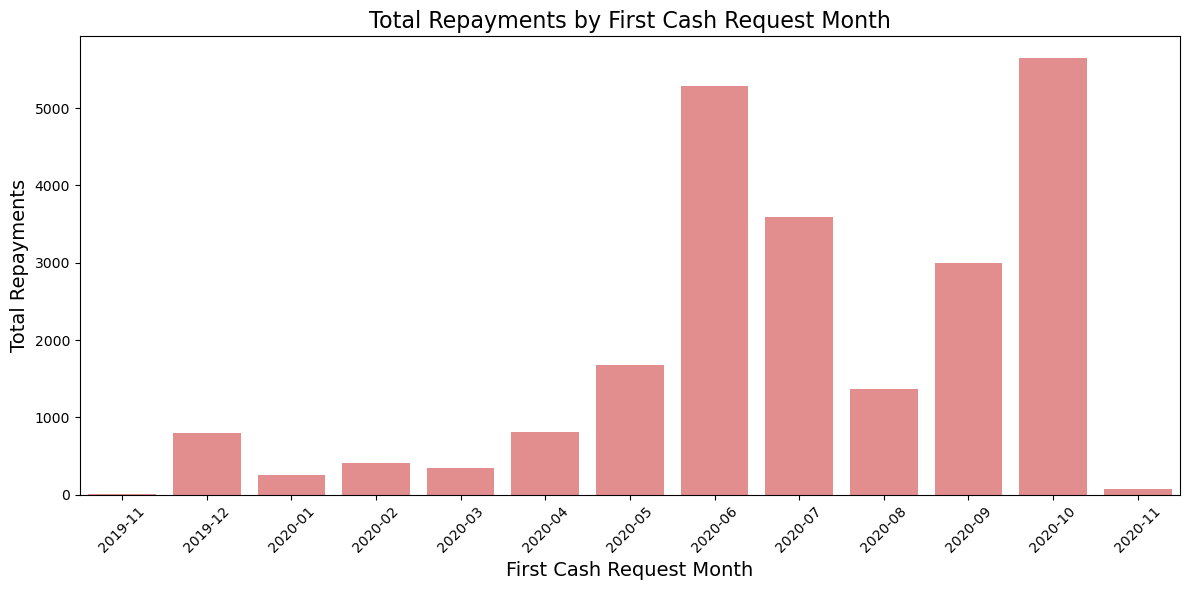

In [50]:
# Visualization of Total Repayments by First Cash Request Month
plt.figure(figsize=(12, 6))
sns.barplot(data=repaid_cohort, x='first_cash_request_month', y='total_money_back', color='lightcoral')
plt.title('Total Repayments by First Cash Request Month', fontsize=16)
plt.xlabel('First Cash Request Month', fontsize=14)
plt.ylabel('Total Repayments', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Total Money Requested and Profits

In [52]:
total_requested = df_combined[df_combined['cash_status'] != 'rejected']['cash_amount'].sum()

total_profits = df_combined[df_combined['fees_status'] != 'cancelled']['total_amount'].sum()

profits_by_status = df_combined.groupby('fees_status')['total_amount'].sum()

print("Total money loaned:", total_requested)
print("Total company profits:", total_profits)
print(f"Percentage gained: {total_profits / total_requested * 100:.2f}%")

print("\nProfits by status:")
print(profits_by_status)

Total money loaned: 2132278.0
Total company profits: 80620.0
Percentage gained: 3.78%

Profits by status:
fees_status
accepted     74210.0
cancelled    24690.0
confirmed      440.0
rejected      5970.0
Name: total_amount, dtype: float64


### Successful refund rate

In [54]:
total_transacciones = df_cash.groupby('year_month').size().reset_index(name='total_transacciones')

# Filtrar transacciones con estado `money_back`
reembolsos = df_combined[df_combined['cash_status'] == 'money_back']

# Calcular el número de reembolsos por cohorte
reembolsos_cohorte = reembolsos.groupby('year_month').size().reset_index(name='total_reembolsos')

# Calcular la tasa de reembolsos por cohorte
tasa_reembolsos = reembolsos_cohorte.merge(total_transacciones, on='year_month')
tasa_reembolsos['tasa_reembolsos_%'] = tasa_reembolsos['total_reembolsos'] / tasa_reembolsos['total_transacciones'] * 100
tasa_reembolsos

,year_month,total_reembolsos,total_transacciones,tasa_reembolsos_%
0,2019-12,154,289,53.287197
1,2020-01,102,223,45.739910
2,2020-02,102,184,55.434783
3,2020-03,165,244,67.622951
4,2020-04,309,473,65.327696
5,2020-05,736,837,87.933094
6,2020-06,2414,2615,92.313576
7,2020-07,2792,3601,77.534018
8,2020-08,3504,3417,102.546093
9,2020-09,4345,4221,102.937692
